# **Predict Students' Dropout and Academic Success**
## Project Overview
This project aims to develop an early warning system to predict whether a student will dropout, enroll, or graduate based on various demographic, socio-economic, and academic performance factors. 
By employing a **Timeline-Based Machine Learning Approach**, we can understand the key factors contributing to student attrition and help institutions intervene early.

## Table of Contents
1. **Data Exploration & Visualization (EDA)**
2. **Feature Engineering**
3. **Model Training & Timeline Evaluation**
4. **Advanced Machine Learning & Deployment Preparation**


# สัดส่วนสถานภาพของนักศึกษาโดยรวม
จากข้อมูลทั้งหมด มีนักศึกษาที่เรียนจบประมาณ 2,209 คน ลาออกกลางคัน 1,421 คน และยังศึกษาอยู่ 794 คน ซึ่งสัดส่วนคนที่ลาออกถือว่าค่อนข้างสูง (ประมาณ 32%)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# โหลดข้อมูล
df = pd.read_csv("Predict Students' Dropout and Academic Success.csv")

# สัดส่วนสถานภาพของนักศึกษาโดยรวม
print("สัดส่วนสถานภาพของนักศึกษา")
target_counts = df['Target'].value_counts()
print(target_counts)
print(f"สัดส่วน Dropout: {(target_counts['Dropout'] / len(df)) * 100:.2f}%\n")

สัดส่วนสถานภาพของนักศึกษา
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
สัดส่วน Dropout: 32.12%



# สัญญาณเตือนล่วงหน้าจากผลการเรียนเทอมแรก
จากกราฟ (1st Semester Approved Units) เราจะเห็นได้ชัดเจนว่า นักศึกษาที่เรียนจบ (Graduate) มักจะสอบผ่านรายวิชาในเทอมแรกได้เยอะมาก (ค่าเฉลี่ยเกาะกลุ่มอยู่ในระดับสูง) ในขณะที่ นักศึกษาที่ลาออก (Dropout) ส่วนใหญ่มีจำนวนวิชาที่สอบผ่านในเทอมแรกน้อยมาก หรือแทบจะไม่ผ่านเลย

/tmp/ipykernel_538/2238353794.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


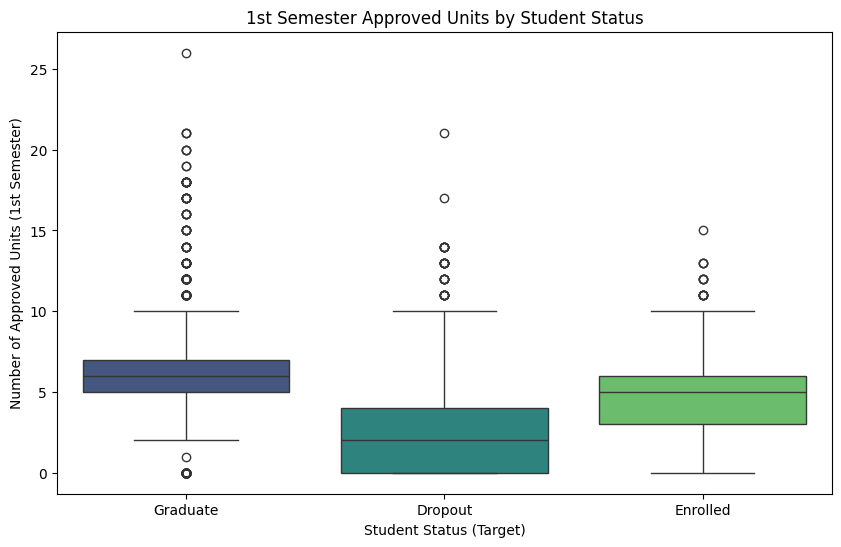

In [ ]:
# สัญญาณเตือนล่วงหน้าจากผลการเรียนเทอมแรก
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='Target',
    y='Curricular units 1st sem (approved)',
    order=['Graduate', 'Dropout', 'Enrolled'],
    palette='viridis'
)
plt.title('1st Semester Approved Units by Student Status')
plt.xlabel('Student Status (Target)')
plt.ylabel('Number of Approved Units (1st Semester)')
plt.show()

# ปัจจัยทางการเงินมีผลอย่างมากต่อการเรียน
จากกราฟ (Tuition Fees Up to Date) หากเราดูสถานะการจ่ายค่าเทอม จะพบความสัมพันธ์ที่น่าสนใจมาก:
นักศึกษาที่ "จ่ายค่าเทอมตรงเวลา (Yes)" มีแนวโน้มที่จะเรียนจบสูงมาก
ในทางกลับกัน นักศึกษาที่ "ค้างชำระค่าเทอม (No)" มีสัดส่วนการลาออก (Dropout) ที่สูงกว่ากลุ่มที่เรียนจบอย่างเห็นได้ชัด

<Figure size 800x500 with 0 Axes>

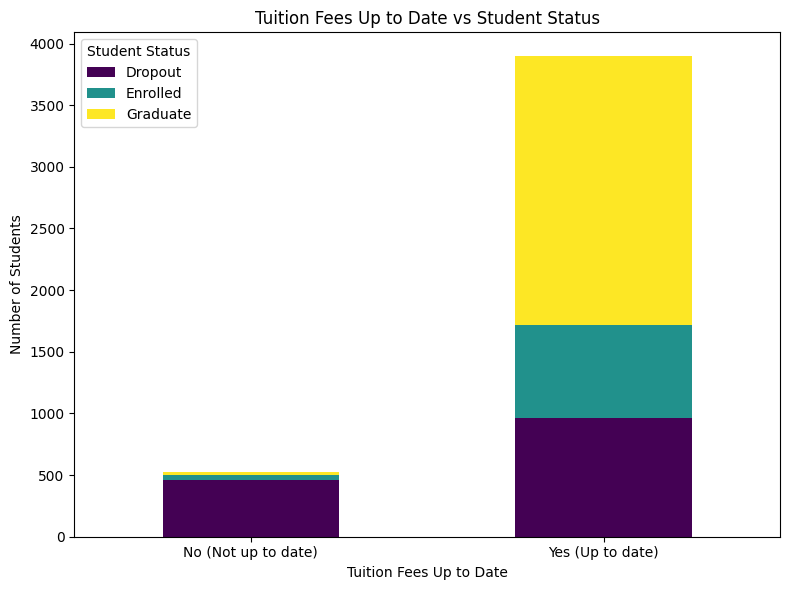

In [ ]:
# ปัจจัยทางการเงินมีผลอย่างมากต่อการเรียน
plt.figure(figsize=(8, 5))
# นับจำนวนนักศึกษาโดยจัดกลุ่มตาม 'การจ่ายค่าเทอม' และ 'สถานภาพ'
fee_data = df.groupby(['Tuition fees up to date', 'Target']).size().unstack()

# เปลี่ยนชื่อ Index ให้เข้าใจง่ายขึ้น (0 = No, 1 = Yes)
fee_data.index = ['No (Not up to date)', 'Yes (Up to date)']

# สร้างกราฟแท่งแบบซ้อนทับ (Stacked Bar Chart)
fee_data.plot(kind='bar', stacked=True, colormap='viridis', figsize=(8, 6))
plt.title('Tuition Fees Up to Date vs Student Status')
plt.xlabel('Tuition Fees Up to Date')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.legend(title='Student Status')
plt.tight_layout()
plt.show()

# หนี้สินของนักศึกษา (Debtor)
ข้อมูลชี้ให้เห็นชัดเจนว่านักศึกษาที่ มีหนี้สินค้างชำระกับมหาวิทยาลัย มีอัตราการลาออกที่พุ่งสูงปรี๊ดถึงประมาณ 62% ในขณะที่คนที่ไม่มีหนี้มีโอกาสลาออกเพียง 28% เท่านั้น

**ความสำคัญ:** นี่เป็นจุดที่บอกได้ว่าปัญหาการเงินคือปัจจัยอันดับต้นๆ ที่ผลักดันให้นักศึกษาต้องเลิกเรียนกลางคัน

อัตราการออกกลางคันเทียบกับการมีหนี้สิน
Target        Dropout  Enrolled  Graduate
No Debt (0)     28.28     17.95     53.76
Has Debt (1)    62.03     17.89     20.08


<Figure size 800x500 with 0 Axes>

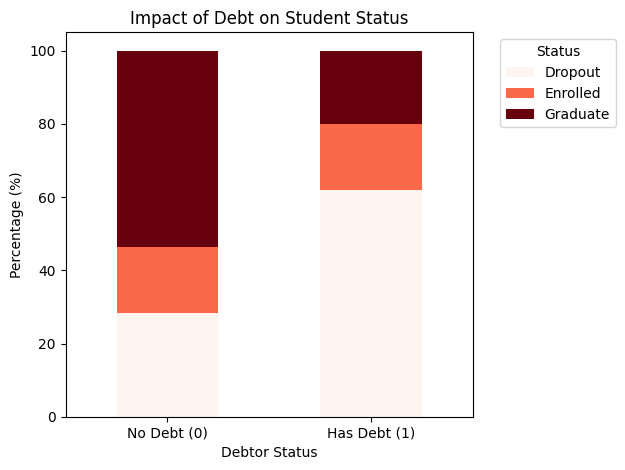

In [ ]:
# หนี้สินของนักศึกษา (Debtor)
print("อัตราการออกกลางคันเทียบกับการมีหนี้สิน")
debtor_stat = df.groupby('Debtor')['Target'].value_counts(normalize=True).unstack() * 100
debtor_stat.index = ['No Debt (0)', 'Has Debt (1)']
print(debtor_stat.round(2))


plt.figure(figsize=(8, 5))
debtor_stat.plot(kind='bar', stacked=True, colormap='Reds')
plt.title('Impact of Debt on Student Status')
plt.xlabel('Debtor Status')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# การได้รับทุนการศึกษา (Scholarship holder)
การมีทุนการศึกษา ช่วยลดอัตราการลาออกได้อย่างมหาศาล! นักศึกษาที่มีทุนมีโอกาสลาออกเหลือเพียงประมาณ 12% ในขณะที่คนที่ไม่มีทุนมีโอกาสลาออกสูงเกือบ 40%

**ความสำคัญ:** มันยืนยันได้ทางสถิติว่า "ทุนการศึกษาช่วยให้นักศึกษาเรียนจนจบได้จริง"

อัตราการออกกลางคันเทียบกับการได้รับทุน
Target               Dropout  Enrolled  Graduate
No Scholarship (0)     38.71     19.97     41.32
Has Scholarship (1)    12.19     11.83     75.98


<Figure size 800x500 with 0 Axes>

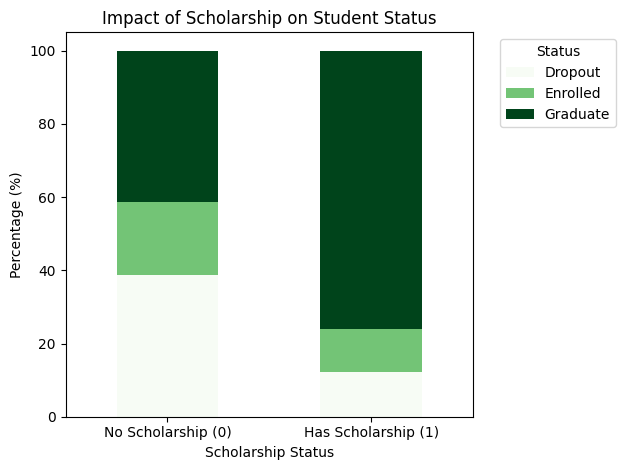

In [ ]:
# การได้รับทุนการศึกษา (Scholarship holder)
print("อัตราการออกกลางคันเทียบกับการได้รับทุน")
schol_stat = df.groupby('Scholarship holder')['Target'].value_counts(normalize=True).unstack() * 100
schol_stat.index = ['No Scholarship (0)', 'Has Scholarship (1)']
print(schol_stat.round(2))

plt.figure(figsize=(8, 5))
schol_stat.plot(kind='bar', stacked=True, colormap='Greens')
plt.title('Impact of Scholarship on Student Status')
plt.xlabel('Scholarship Status')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ช่องว่างทางเพศในการเรียนจบ
จากข้อมูล พบความน่าสนใจว่า นักศึกษาชาย มีอัตราการลาออกสูงถึง 45% ซึ่งสูงกว่านักศึกษาหญิง ที่มีอัตราลาออกเพียง 25% เกือบเท่าตัว!

**ความสำคัญ:** เกิดอะไรขึ้นกับนักศึกษาชาย? ทำไมถึงมีแนวโน้มจะเรียนไม่จบมากกว่า? อาจเกี่ยวกับการต้องออกไปทำงานหาเงิน หรือพฤติกรรมการใช้ชีวิต

อัตราการออกกลางคันเทียบกับเพศ
Target      Dropout  Enrolled  Graduate
Female (0)    25.10     16.98     57.91
Male (1)      45.05     19.73     35.22


<Figure size 800x500 with 0 Axes>

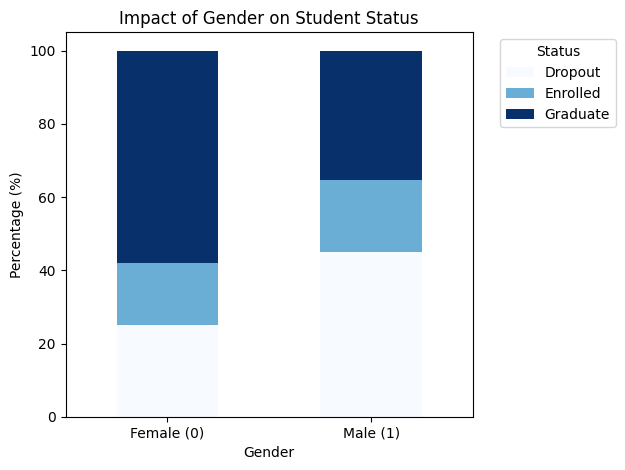

In [ ]:
# เพศ (Gender)
print("อัตราการออกกลางคันเทียบกับเพศ")
gender_stat = df.groupby('Gender')['Target'].value_counts(normalize=True).unstack() * 100
# อ้างอิงจากข้อมูล Metadata: 0 = หญิง, 1 = ชาย
gender_stat.index = ['Female (0)', 'Male (1)']
print(gender_stat.round(2))

plt.figure(figsize=(8, 5))
gender_stat.plot(kind='bar', stacked=True, colormap='Blues')
plt.title('Impact of Gender on Student Status')
plt.xlabel('Gender')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# อายุตอนเข้าเรียน (Age at enrollment)
หากสร้างกราฟ Boxplot ดูการกระจายตัวของอายุ จะพบว่านักศึกษาที่จัดอยู่ในกลุ่ม Dropout มักจะมีอายุเฉลี่ยตอนเข้าเรียนที่ "สูงกว่า" กลุ่มที่เรียนจบ

**ความสำคัญ:** นักศึกษาที่เข้าเรียนตอนอายุมากมักเป็นผู้ใหญ่ที่ทำงานไปด้วยหรือมีครอบครัวแล้ว (Adult learners) ทำให้มีภาระและความกดดันด้านเวลามากกว่า

ค่าเฉลี่ยอายุตอนเข้าเรียนแยกตามสถานภาพ
Target
Dropout     26.07
Enrolled    22.37
Graduate    21.78
Name: Age at enrollment, dtype: float64


/tmp/ipykernel_199/1291049153.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


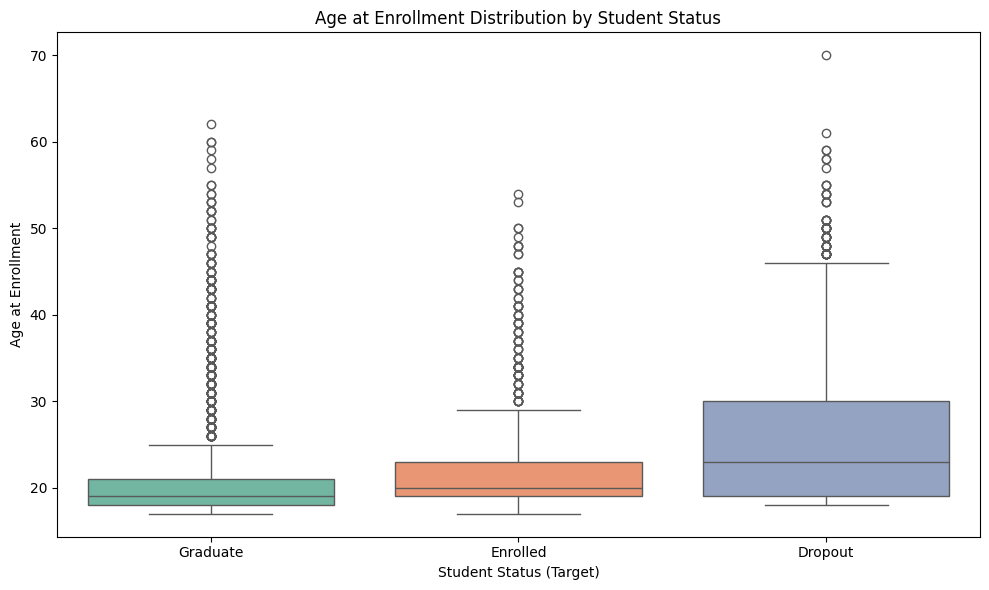

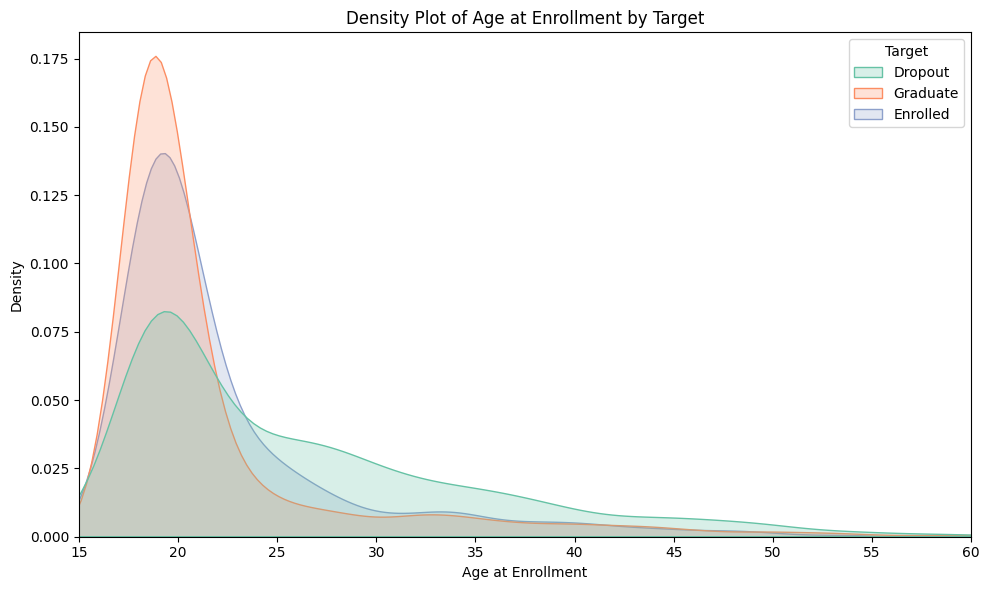

In [ ]:
# อายุตอนเข้าเรียน (Age at enrollment)
print("ค่าเฉลี่ยอายุตอนเข้าเรียนแยกตามสถานภาพ")
age_stat = df.groupby('Target')['Age at enrollment'].mean()
print(age_stat.round(2))

# สร้างกราฟ Boxplot เพื่อดูการกระจายตัวของอายุในแต่ละกลุ่ม
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='Target',
    y='Age at enrollment',
    order=['Graduate', 'Enrolled', 'Dropout'],
    palette='Set2'
)
plt.title('Age at Enrollment Distribution by Student Status')
plt.xlabel('Student Status (Target)')
plt.ylabel('Age at Enrollment')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Age at enrollment', hue='Target', fill=True, common_norm=False, palette='Set2')
plt.title('Density Plot of Age at Enrollment by Target')
plt.xlabel('Age at Enrollment')
plt.xlim(15, 60)
plt.tight_layout()
plt.show()

# **RandomForestClassifier**
# สรุปข้อค้นพบที่สำคัญจากโปรเจกต์ (Key Discoveries & Insights)
**Phase 1 (Day-1):** แม้จะยังไม่มีข้อมูลเกรดระดับมหาวิทยาลัยเลย (ใช้วันแรกที่มอบตัว) โมเดลก็สามารถทำนายได้แม่นยำถึง 77% ว่าใครจะรอดหรือใครจะลาออก โดยวิเคราะห์จากอายุ, เกรดมัธยม, และสถานะการจ่ายค่าเทอมแรกเข้า

**Phase 2 (End of Sem 1):** เมื่อนักศึกษาเรียนจบเทอม 1 และนำข้อมูลผลการเรียนมาร่วมประเมิน ความแม่นยำของระบบจะกระโดดขึ้นไปเกือบ 88%

**สรุปข้อเสนอแนะสำหรับมหาวิทยาลัย (Actionable Recommendations):** มหาวิทยาลัยไม่จำเป็นต้องรอให้ผลการเรียนของนักศึกษาตกต่ำลงจนแก้ไขไม่ได้ แต่สามารถใช้ข้อมูล Day-1 เข้ามาประเมินความเสี่ยงได้ทันที เพื่อจัดสรรงบประมาณ "ทุนการศึกษาฉุกเฉิน" หรือจัดทีมอาจารย์ที่ปรึกษา (Counseling) เข้าไปดูแลกลุ่มนักศึกษาที่มีปัญหาด้านการเงินและกลุ่มนักศึกษาที่มีอายุมาก ตั้งแต่วันแรกที่ก้าวเข้ามาในมหาวิทยาลัย

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. โหลดข้อมูลและเตรียม Data
df = pd.read_csv("Predict Students' Dropout and Academic Success.csv")

# กรองเฉพาะคนที่ จบ (Graduate) และ ลาออก (Dropout) เพื่อทำ Binary Classification
df_model = df[df['Target'].isin(['Dropout', 'Graduate'])]
X = df_model.drop('Target', axis=1)
y = df_model['Target']

# สร้างชุดข้อมูลตาม "Timeline"
# ดึงชื่อคอลัมน์ที่เป็นผลการเรียนเทอม 1 และ เทอม 2 ออกมา
sem1_features = [col for col in X.columns if '1st sem' in col]
sem2_features = [col for col in X.columns if '2nd sem' in col]

# ข้อมูลชุดที่ 1 (Day 1): วันแรกเข้า (ไม่มีเกรดมหาลัย) ตัดเทอม 1 และ 2 ทิ้ง
X_day1 = X.drop(columns=sem1_features + sem2_features)

# ข้อมูลชุดที่ 2 (End of Sem 1): จบเทอม 1 (มีแค่เกรดเทอม 1) ตัดเทอม 2 ทิ้ง
X_sem1 = X.drop(columns=sem2_features)

# แบ่งข้อมูลสำหรับ Train / Test (ใช้ Random State 42 )
y_binary = y.map({'Dropout': 0, 'Graduate': 1}) # แปลง Target เป็น 0, 1 เพื่อง่ายต่อการวัดผล
X_train_d1, X_test_d1, y_train, y_test = train_test_split(X_day1, y_binary, test_size=0.2, random_state=42)
X_train_s1, X_test_s1, _, _ = train_test_split(X_sem1, y_binary, test_size=0.2, random_state=42)

# ฝึกสอนโมเดล (Random Forest)
# สร้างฟังก์ชัน
def train_and_evaluate(X_train, X_test, y_train, y_test, title):
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"{title}")
    print(f"Accuracy: {acc*100:.2f}%")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Dropout', 'Graduate']))
    return rf


รันโมเดลเปรียบเทียบ 2 ช่วงเวลา

In [ ]:
# รันโมเดลเปรียบเทียบ 2 ช่วงเวลา
model_day1 = train_and_evaluate(X_train_d1, X_test_d1, y_train, y_test, "Model 1: Day-1 Prediction (No University Grades)")
print("\n" + "-"*54 + "\n")
model_sem1 = train_and_evaluate(X_train_s1, X_test_s1, y_train, y_test, "Model 2: End of Semester 1 Prediction")

Model 1: Day-1 Prediction (No University Grades)
Accuracy: 77.27%
Classification Report:
              precision    recall  f1-score   support

     Dropout       0.73      0.64      0.68       277
    Graduate       0.79      0.86      0.82       449

    accuracy                           0.77       726
   macro avg       0.76      0.75      0.75       726
weighted avg       0.77      0.77      0.77       726


------------------------------------------------------

Model 2: End of Semester 1 Prediction
Accuracy: 87.74%
Classification Report:
              precision    recall  f1-score   support

     Dropout       0.90      0.76      0.83       277
    Graduate       0.87      0.95      0.91       449

    accuracy                           0.88       726
   macro avg       0.88      0.86      0.87       726
weighted avg       0.88      0.88      0.88       726



/tmp/ipykernel_199/1634059021.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='magma')


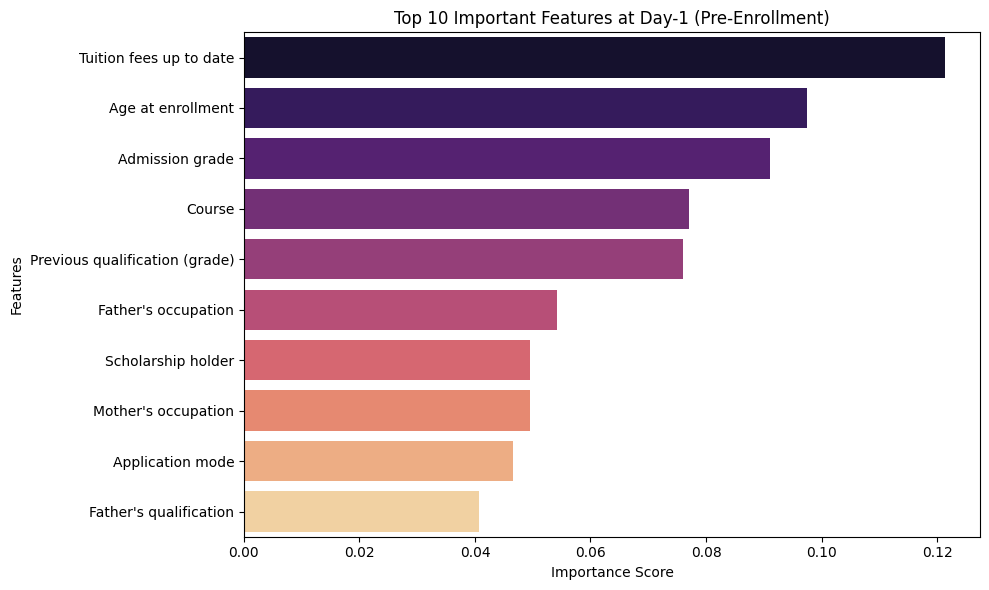

In [ ]:
# ดู Feature Importance ของโมเดล Day-1 อะไรทำให้ออกตั้งแต่วันแรก
importances = pd.DataFrame({
    'Feature': X_day1.columns,
    'Importance': model_day1.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='magma')
plt.title('Top 10 Important Features at Day-1 (Pre-Enrollment)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# **4. Advanced Machine Learning & Deployment Preparation**
## 4.1 Hyperparameter Tuning
To ensure our model achieves the best possible performance, we will perform Hyperparameter Tuning on the Day-1 model using `GridSearchCV`. This process searches for the optimal combination of parameters for the Random Forest Classifier.


In [ ]:
from sklearn.model_selection import GridSearchCV
import joblib

print("Starting Hyperparameter Tuning for Day-1 Random Forest...")

# Defining parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Base model
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# GridSearchCV setup (cv=3 for faster execution during demonstration)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, scoring='accuracy', verbose=1)

# Fit GridSearchCV 
grid_search.fit(X_train_d1, y_train)

# Best model
best_rf_day1 = grid_search.best_estimator_
print(f"\nBest Parameters Found: {grid_search.best_params_}")

# Evaluate best model
y_pred_tuned = best_rf_day1.predict(X_test_d1)
print(f"\nTuned Model Accuracy: {accuracy_score(y_test, y_pred_tuned)*100:.2f}%")
print("Classification Report (Tuned):")
print(classification_report(y_test, y_pred_tuned, target_names=['Dropout', 'Graduate']))


## 4.2 Model Deployment Preparation
Now that we have an optimized model for Day-1 predictions, we can save it to disk. This serialized model (`predict_dropout_model.pkl`) can then be integrated into a web application or an internal dashboard for real-time predictions.


In [ ]:
# Save the best trained model to disk
model_filename = 'predict_dropout_model.pkl'
joblib.dump(best_rf_day1, model_filename)

print(f"Model successfully saved to {model_filename}")
print("The model is now ready for deployment in a production environment!")
